In [21]:
import polars as pl
import pandas as pd
# polars is faster for cpu bound preprocess

In [22]:
df = pl.read_csv("../data/raw/1000502_19251231_to_20251231.csv")

len(df)

15982

In [23]:
df.head()

INDNO,YYYYMMDD,DlyCalDt,DlyTotRet,DlyTotInd,DlyPrcRet,DlyPrcInd,DlyIncRet,DlyIncInd,DlyUsdCnt,DlyUsdVal,DlyTotCnt,DlyTotVal,DlyEligCnt,DlyWgtAmt,INDFAM,IndFamType,IndNm,IndBegDt,IndEndDt,BaseLvl,BaseDt,FreqAvail,WeightType,CntValType,PortNum
i64,i64,str,str,str,f64,f64,str,str,str,str,str,str,str,str,i64,str,str,str,str,f64,str,str,str,str,i64
1000502,20110425,"""2011-04-25""",null,null,-0.001593,1335.25,null,null,null,null,null,null,null,null,1100502,"""L""","""S&P 500 Composite""","""1962-07-02""","""2025-12-31""",10.0,"""1923-01-01""","""BTH""","""X""","""N/A""",1
1000502,20030307,"""2003-03-07""",null,null,0.008259,828.89,null,null,null,null,null,null,null,null,1100502,"""L""","""S&P 500 Composite""","""1962-07-02""","""2025-12-31""",10.0,"""1923-01-01""","""BTH""","""X""","""N/A""",1
1000502,19861211,"""1986-12-11""",null,null,-0.011117,248.17,null,null,null,null,null,null,null,null,1100502,"""L""","""S&P 500 Composite""","""1962-07-02""","""2025-12-31""",10.0,"""1923-01-01""","""BTH""","""X""","""N/A""",1
1000502,20190614,"""2019-06-14""",null,null,-0.001612,2886.98,null,null,null,null,null,null,null,null,1100502,"""L""","""S&P 500 Composite""","""1962-07-02""","""2025-12-31""",10.0,"""1923-01-01""","""BTH""","""X""","""N/A""",1
1000502,19990208,"""1999-02-08""",null,null,0.003526,1243.77,null,null,null,null,null,null,null,null,1100502,"""L""","""S&P 500 Composite""","""1962-07-02""","""2025-12-31""",10.0,"""1923-01-01""","""BTH""","""X""","""N/A""",1


In [24]:
df.null_count()

INDNO,YYYYMMDD,DlyCalDt,DlyTotRet,DlyTotInd,DlyPrcRet,DlyPrcInd,DlyIncRet,DlyIncInd,DlyUsdCnt,DlyUsdVal,DlyTotCnt,DlyTotVal,DlyEligCnt,DlyWgtAmt,INDFAM,IndFamType,IndNm,IndBegDt,IndEndDt,BaseLvl,BaseDt,FreqAvail,WeightType,CntValType,PortNum
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,15982,15982,1,0,15982,15982,15982,15982,15982,15982,15982,15982,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df = df.with_columns(
    pl.col("YYYYMMDD").cast(pl.String).str.to_date("%Y%m%d")

    
) # parse date from int to date

has_data = df.select(pl.all().is_not_null().any())
cols_to_keep = [col for col in df.columns if has_data[col][0]]

df_clean = df.select(cols_to_keep)
df_clean.columns


['INDNO',
 'YYYYMMDD',
 'DlyCalDt',
 'DlyPrcRet',
 'DlyPrcInd',
 'INDFAM',
 'IndFamType',
 'IndNm',
 'IndBegDt',
 'IndEndDt',
 'BaseLvl',
 'BaseDt',
 'FreqAvail',
 'WeightType',
 'CntValType',
 'PortNum']

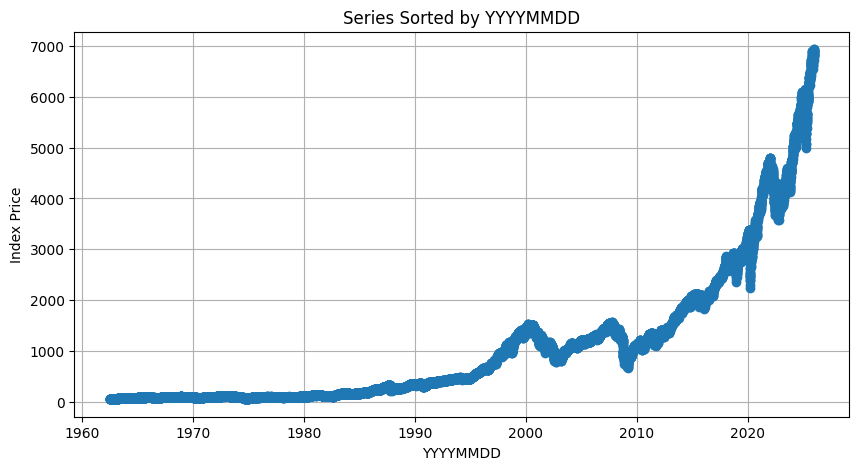

In [26]:
import matplotlib.pyplot as plt

df_sorted = df_clean.sort("YYYYMMDD")

plt.figure(figsize=(10, 5))
plt.plot(
    df_sorted["YYYYMMDD"].to_numpy(),
    df_sorted["DlyPrcInd"].to_numpy(),
    marker="o",
    linestyle="-",
)

plt.xlabel("YYYYMMDD")
plt.ylabel("Index Price")
plt.title("Series Sorted by YYYYMMDD")
plt.grid(True)
plt.show()

In [29]:
df_selected = df_sorted.select(
    pl.col(["YYYYMMDD", "DlyPrcInd", "DlyPrcRet", "DlyPrcInd"])
)

df_selected.write_csv("../data/processed/sp500_index_price.csv")